# EOPF: Sentinel‑2 UTM → HEALPix (Level‑1C)

**Audience:** Researchers, Data Scientists
**Last updated:** 2025-09-09

This notebook demonstrates a clear, reproducible workflow to convert Sentinel‑2 L1C data
from its native UTM projection to a global **HEALPix** grid, following the style of the
[EOPF Sentinel‑2 examples].

**You will learn to:**
- Access cloud‑native Sentinel‑2 Zarr data (via STAC/EOPF)
- Subset a region of interest (ROI)
- Attach latitude/longitude coordinates to UTM gridded data
- Reproject/aggregate onto a **HEALPix** equal‑area grid
- Inspect and save the result for downstream analysis

**Prerequisites:** Python, Xarray, familiarity with EO data, basic projections.

> Tip: Run the notebook top‑to‑bottom in a fresh environment for best results.

## Table of Contents

1. [Introduction](#introduction)
2. [Environment & Dependencies](#environment--dependencies)
3. [Data Access via STAC](#data-access-via-stac)
4. [Open the Sentinel‑2 Product](#open-the-sentinel2-product)
5. [Subset a Region of Interest](#subset-a-region-of-interest)
6. [Quicklook & Visualization](#quicklook--visualization)
7. [Add Latitude/Longitude Coordinates](#add-latitudelongitude-coordinates)
8. [Convert to HEALPix](#convert-to-healpix)
9. [Inspect the HEALPix Output](#inspect-the-healpix-output)
10. [Save & Export](#save--export)
11. [Appendix / References](#appendix--references)

## Introduction

Sentinel‑2 Level‑1C products are distributed in **UTM** tiles (projected meters). Many global
analyses benefit from a sphere‑aware, **equal‑area** grid. **HEALPix** (Hierarchical Equal Area
isoLatitude Pixelization) partitions the globe into equal‑area cells, making aggregations and
comparisons consistent across latitudes. This notebook restructures the original workflow with
clear chapters and explanations while preserving all original code and outputs.

This is a **Skelton** Notebook Converting EOPF Zarr format in UTM to HEALPix;
We use EOPF Sample service data here.
Since EOPF data is based on Datatree, we use that property. Thus this workflow can be applied to any UTM expressed EOPF ZARR format. (cf S2L1 and S2L2A)

## Setting up enviroment

In [1]:
#!pip install xarray-eopf  xdggs healpix-geo

### Imports and setup

- Loads libraries: matplotlib, numpy, xarray. Configures plotting options.

In [2]:
import numpy as np
import pyproj
import pystac_client
import xarray as xr

## Data Access via STAC

We query the EOPF STAC catalog for a suitable Sentinel‑2 L1C item (e.g., low cloud cover, good sun elevation) and obtain the Zarr asset. This keeps the workflow cloud‑native and lazily loaded.

### Open datasets with Xarray


- Opens datasets using Xarray (lazy loading with Dask if chunked).
- To run this notebook with "sentinel-2-l1c", or "sentinel-2-l2a", simply specify it on the collections
-


In [3]:
dt = xr.open_datatree(
    "https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202506-s02msil1c/17/products/cpm_v256/S2B_MSIL1C_20250617T112109_N0511_R037_T30UUU_20250617T131418.zarr",
    chunks={},
    engine="eopf-zarr",
    op_mode="native",
)
dt

<xarray.DataTree>
Group: /
│   Attributes: (3)
├── Group: /conditions
│   ├── Group: /conditions/geometry
│   │       Dimensions:                        (angle: 2, band: 13, y: 23, x: 23,
│   │                                           detector: 7)
│   │       Coordinates:
│   │         * angle                          (angle) <U7 56B 'zenith' 'azimuth'
│   │         * band                           (band) <U3 156B 'b01' 'b02' ... 'b11' 'b12'
│   │         * detector                       (detector) int64 56B 3 4 5 6 7 8 9
│   │         * x                              (x) int64 184B 300000 305000 ... 410000
│   │         * y                              (y) int64 184B 5400000 5395000 ... 5290000
│   │       Data variables:
│   │           mean_sun_angles                (angle) float64 16B dask.array<chunksize=(2,), meta=np.ndarray>
│   │           mean_viewing_incidence_angles  (band, angle) float64 208B dask.array<chunksize=(13, 2), meta=np.ndarray>
│   │           sun_angles                     (angle, y, x) float64 8kB dask.array<chunksize=(2, 23, 23), meta=np.ndarray>
│   │           viewing_incidence_angles       (band, detector, angle, y, x) float64 770kB dask.array<chunksize=(7, 4, 2, 23, 23), meta=np.ndarray>
│   ├── Group: /conditions/mask
│   │   ├── Group: /conditions/mask/detector_footprint
│   │   │   ├── Group: /conditions/mask/detector_footprint/r10m
│   │   │   │       Dimensions:  (y: 10980, x: 10980)
│   │   │   │       Coordinates:
│   │   │   │         * x        (x) int64 88kB 300005 300015 300025 300035 ... 409775 409785 409795
│   │   │   │         * y        (y) int64 88kB 5399995 5399985 5399975 ... 5290225 5290215 5290205
│   │   │   │       Data variables:
│   │   │   │           b02      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   │           b03      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   │           b04      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   │           b08      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   ├── Group: /conditions/mask/detector_footprint/r20m
│   │   │   │       Dimensions:  (y: 5490, x: 5490)
│   │   │   │       Coordinates:
│   │   │   │         * x        (x) int64 44kB 300010 300030 300050 300070 ... 409750 409770 409790
│   │   │   │         * y        (y) int64 44kB 5399990 5399970 5399950 ... 5290250 5290230 5290210
│   │   │   │       Data variables:
│   │   │   │           b05      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b06      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b07      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b11      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b12      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b8a      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   └── Group: /conditions/mask/detector_footprint/r60m
│   │   │           Dimensions:  (y: 1830, x: 1830)
│   │   │           Coordinates:
│   │   │             * x        (x) int64 15kB 300030 300090 300150 300210 ... 409650 409710 409770
│   │   │             * y        (y) int64 15kB 5399970 5399910 5399850 ... 5290350 5290290 5290230
│   │   │           Data variables:
│   │   │               b01      (y, x) uint8 3MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
│   │   │               b09      (y, x) uint8 3MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
│   │   │               b10      (y, x) uint8 3MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
│   │   └── Group: /conditions/mask/l1c_classification
│   │       └── Group: /conditions/mask/l1c_classification/r60m
│   │               Dimensions:  (y: 1830, x: 18

## Open the Sentinel‑2 Product

We open the product directly as an **Xarray DataTree** (lazy) to navigate measurements, conditions, and multi‑resolution groups (10m/20m/60m).

## Subset a Region of Interest

We extract a small ROI (e.g., a 3×3 window) to demonstrate transformation and HEALPix conversion on a compact example.

In [4]:
# chose small area in UTM
## TODO, we can update here to chose  'one detection' area.

small_dt = dt.sel(
    x=slice(
        dt["conditions"]["geometry"]["sun_angles"].x[0],
        dt["conditions"]["geometry"]["sun_angles"].x[1],
    ),
    y=slice(
        dt["conditions"]["geometry"]["sun_angles"].y[-2],
        dt["conditions"]["geometry"]["sun_angles"].y[-1],
    ),
)

In [5]:
dt["conditions"]["geometry"]["sun_angles"]

<xarray.DataArray 'sun_angles' (angle: 2, y: 23, x: 23)> Size: 8kB
dask.array<open_dataset-sun_angles, shape=(2, 23, 23), dtype=float64, chunksize=(2, 23, 23), chunktype=numpy.ndarray>
Coordinates:
  * angle    (angle) <U7 56B 'zenith' 'azimuth'
  * x        (x) int64 184B 300000 305000 310000 315000 ... 400000 405000 410000
  * y        (y) int64 184B 5400000 5395000 5390000 ... 5300000 5295000 5290000
Attributes: (1)

## Quicklook & Visualization

We visualize one or more bands (e.g., B02) to confirm the ROI and interpret pixel values before reprojection.

In [16]:
# We see , probably a boat.
# Todo, add plot for small_dt['conditions']['l1c_quicklook']['r10m']
# small_dt['conditions']['l1c_quicklook']['r10m'].hvplot.rgb(x='x',y='y', )

small_dt["measurements"]["reflectance"]["r10m"]["b02"].plot()

<xarray.DataArray 'b02' (y: 480, x: 500)> Size: 2MB
dask.array<getitem, shape=(480, 500), dtype=float64, chunksize=(480, 500), chunktype=numpy.ndarray>
Coordinates:
  * x        (x) int64 4kB 300005 300015 300025 300035 ... 304975 304985 304995
  * y        (y) int64 4kB 5294995 5294985 5294975 ... 5290225 5290215 5290205
Attributes: (12)

## Add Latitude/Longitude Coordinates

Using **pyproj** we transform UTM (x/y in meters) to geographic coordinates (lon/lat in degrees) and attach them as auxiliary coordinates. This enables subsequent binning onto a spherical grid.

### Annotate UTM with latitude and Longitude

In [7]:
def _add_latlon(ds: xr.Dataset, transformer: pyproj.Transformer) -> xr.Dataset:
    """Attach latitude/longitude coords + CF metadata to a Dataset with (x,y)."""
    if not {"x", "y"}.issubset(ds.dims):
        return ds

    xx, yy = np.meshgrid(ds["x"].values, ds["y"].values, indexing="xy")
    lon, lat = transformer.transform(xx, yy)

    ds = ds.assign_coords(
        longitude=(("y", "x"), lon),
        latitude=(("y", "x"), lat),
    )
    ds["latitude"].attrs.update(
        {
            "standard_name": "latitude",
            "long_name": "Latitude",
            "units": "degrees_north",
            "axis": "Y",
        }
    )
    ds["longitude"].attrs.update(
        {
            "standard_name": "longitude",
            "long_name": "Longitude",
            "units": "degrees_east",
            "axis": "X",
        }
    )

    # Make sure vars with (y,x) advertise the aux coords
    for var in ds.data_vars:
        if {"y", "x"}.issubset(ds[var].dims):
            existing = ds[var].attrs.get("coordinates", "").split()
            ds[var].attrs["coordinates"] = " ".join(
                sorted(set(existing) | {"latitude", "longitude"})
            )
    return ds


def add_latlon(
    path: str, ds: xr.Dataset, transformer: pyproj.Transformer
) -> xr.Dataset:
    """Wrapper for safe application on a node dataset."""
    if ds is None:
        print(path, "no dataset")
        return ds
    if not {"x", "y"}.issubset(ds.dims):
        print(path, "not both x,y")
        return ds
    return _add_latlon(ds, transformer)


def add_latlon_to_dt(dt: xr.DataTree) -> xr.DataTree:
    """Return a new DataTree with latitude/longitude coords added everywhere possible."""
    crs_code = dt.attrs["other_metadata"]["horizontal_CRS_code"]
    src_crs = pyproj.CRS.from_string(crs_code)
    transformer = pyproj.Transformer.from_crs(
        src_crs, pyproj.CRS.from_epsg(4326), always_xy=True
    )
    return xr.DataTree.from_dict(
        {
            path: add_latlon(path, node.ds, transformer)
            for path, node in dt.subtree_with_keys
        }
    )

In [8]:
%%time
latlon_dt = add_latlon_to_dt(small_dt)

. not both x,y
conditions not both x,y
measurements not both x,y
quality not both x,y
conditions/mask not both x,y
conditions/meteorology not both x,y
measurements/reflectance not both x,y
quality/l1c_quicklook not both x,y
quality/mask not both x,y
conditions/mask/detector_footprint not both x,y
conditions/mask/l1c_classification not both x,y
conditions/meteorology/cams not both x,y
conditions/meteorology/ecmwf not both x,y
CPU times: user 292 ms, sys: 24 μs, total: 292 ms
Wall time: 290 ms


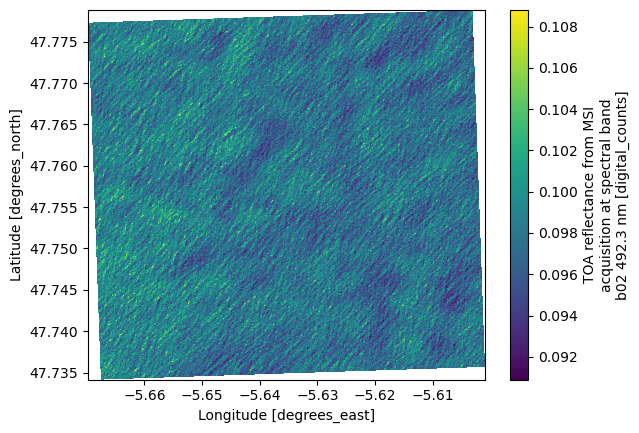

In [9]:
latlon_dt["measurements"]["reflectance"]["r10m"]["b02"].plot(
    x="longitude", y="latitude"
)

## Conversion to HEALPix

We check dimensions and metadata (e.g., `cell_ids`, level, indexing scheme) and ensure variables were preserved.

In [10]:
import pathlib
from healpix_geo.nested import lonlat_to_healpix


# --- level selection (coarsest grid not finer than dx) ---
EARTH_RADIUS_M = 6_371_000.0  # radius used in healpix-geo levels table


def _healpix_edge_length_m(level: int, radius_m: float = EARTH_RADIUS_M) -> float:
    # edge = R * sqrt(pi/3) / 2**level  (matches healpix-geo "levels" page)
    return radius_m * np.sqrt(np.pi / 3.0) / (2**level)


def _infer_dx_from_x(ds: xr.Dataset) -> float:
    x = np.asarray(ds["x"].values)
    dx = float(np.nanmedian(np.abs(np.diff(x))))
    if not np.isfinite(dx) or dx <= 0:
        raise ValueError("Could not infer a positive spacing from ds['x'].")
    return dx


def _choose_healpix_level_from_dx(
    ds: xr.Dataset, min_level: int = 0, max_level: int = 29
) -> int:
    dx = _infer_dx_from_x(ds)
    base = EARTH_RADIUS_M * np.sqrt(np.pi / 3.0)
    level = int(np.floor(np.log2(base / dx)))  # edge(level) >= dx
    return int(np.clip(level, min_level, max_level))


# --- single-dataset transform -> grouped by unique HEALPix cell_ids ---
def _to_healpix_cells_grouped_mean(
    ds: xr.Dataset, level: int | None = None, ellipsoid: str = "WGS84"
) -> xr.Dataset:
    """
    Returns a dataset with dims (angle, cell_ids), where 'cell_ids' is a
    dimension/coordinate containing unique HEALPix ids (NESTED).
    Values are averaged over all source samples that mapped to the same cell.
    """
    if not {"y", "x"}.issubset(ds.dims):
        raise ValueError("Dataset must have 'y' and 'x' dimensions.")
    if not {"latitude", "longitude"}.issubset(ds.coords):
        raise ValueError(
            "Dataset must have 'latitude' and 'longitude' coords (degrees)."
        )

    if level is None:
        level = _choose_healpix_level_from_dx(ds)

    # 1) hash each (lon,lat) to HEALPix nested cell id
    lon = ds["longitude"].values.ravel()
    lat = ds["latitude"].values.ravel()
    cell_ids = lonlat_to_healpix(lon, lat, level, ellipsoid=ellipsoid)

    # 2) stack (y,x) -> cells
    out = ds.stack(cells=("y", "x"))

    # 3) attach cell_ids coord on 'cells'
    out = out.assign_coords(cell_ids=("cells", cell_ids.astype("int64")))
    out["cell_ids"].attrs.update({"standard_name": "healpix", "units": "1"})
    cell_ids_attrs = dict(out["cell_ids"].attrs)  # keep for after groupby

    # 4) drop redundant coords/vars
    #    drop_these = [n for n in ("x", "y", "latitude", "longitude") if n in out.variables]
    #    out = out.drop_vars(drop_these)

    # 5) group by cell_ids and average
    # **note** This is a very simplified test conversion,
    # later this should be updated spline other interpolation methods.
    out = out.groupby("cell_ids").mean().rename_dims(cell_ids="cells")

    # 6) restore attrs on the new dimension coordinate
    if "cell_ids" in out.coords:
        out["cell_ids"].attrs.update(cell_ids_attrs)

    # 7) keep order stable for variables like (angle, cell_ids)
    #   for v in out.data_vars:
    #       if ("angle" in out[v].dims) and ("cell_ids" in out[v].dims):
    #           out[v] = out[v].transpose("angle", "cell_ids", ...)

    return out


def _update_group_metadata(
    ds: xr.Dataset,
    level: int,
    ellipsoid: str = "WGS84",
    grid_mapping_var_name: str = "crs",
) -> xr.Dataset:
    """Update metadata of a single group."""

    if "cells" not in ds.dims:
        return ds

    ds_healpix = ds.copy()

    # create healpix grid mapping variable
    ds_healpix.coords[grid_mapping_var_name] = (
        (),
        0,
        {
            "grid_mapping_name": "healpix",
            "indexing_scheme": "nested",
            "refinement_ratio": 4,
            "refinement_level": level,
            "reference_body": ellipsoid,
        },
    )

    # update variable attributes
    # dimensions, coordinates and grid_mapping attributes
    # clean-up non-healpix variable attributes
    for var_name, var in ds_healpix.variables.items():
        if "cells" in var.dims:
            attrs = var.attrs.copy()
            eopf_attrs = attrs.get("_eopf_attrs", None)
            if eopf_attrs is not None:
                eopf_attrs["dimensions"] = ["cells"]
                eopf_attrs["coordinates"] = ["cell_ids"]
            for name in var.attrs:
                if "proj:" in name:
                    del attrs[name]
            if "coordinates" in var.attrs:
                attrs["coordinates"] = "cell_ids"
            if var_name != "cell_ids":
                attrs["grid_mapping"] = grid_mapping_var_name
            var.attrs = attrs

    return ds_healpix


# --- HEALPix group converter ---
def _add_healpix_to_group(path: str, ds: xr.Dataset) -> tuple[xr.Dataset, int | None]:
    if ds is None:
        print(path, "no dataset — keeping empty group")
        return xr.Dataset()

    has_xy = {"x", "y"}.issubset(ds.dims)
    has_ll = {"latitude", "longitude"}.issubset(ds.coords)

    if has_xy and not has_ll:
        # stop the whole operation as requested
        raise RuntimeError(
            f"{path}: has x/y but missing latitude/longitude — aborting."
        )

    if has_ll and has_xy:
        level = _choose_healpix_level_from_dx(ds)
        print(
            f"{path}: chosen level {level} (edge≈{_healpix_edge_length_m(level):.4f} m)"
        )
        ds_healpix = _to_healpix_cells_grouped_mean(ds, level=level, ellipsoid="WGS84")
        ds_healpix = _update_group_metadata(ds_healpix, level=level, ellipsoid="WGS84")
        return ds_healpix, level

    # no lat/lon -> do nothing
    print(path, "no latitude/longitude — skipping")
    return ds, None


def _update_stac_discovery(attrs: dict):
    """Update product level STAC."""

    # TODO: update "bbox" and "geometry" attributes to
    # so it is consistent with HEALPix cell geometries

    props = attrs["properties"].copy()

    # remove irrelevant properties for HEALPix
    for k in attrs["properties"]:
        if "proj:" in k:
            del props[k]

    # TODO: add STAC discovery "grid:code" property
    # "grid:code" value is formatted like "HEALPIX-I{indexing_scheme}-L{level}-{cell_id}"
    # use a placeholder cell id value for now (to be defined)
    #props["grid:code"] = "HEALPIX-Inested-L10-1234"
    #attrs["stac_extensions"].append(
    #    "https://stac-extensions.github.io/grid/v1.1.0/schema.json"
    #)

    # TODO: update "bbox" and "geometry" attribute values.

    attrs["properties"] = props


# --- public function: apply over the whole DataTree ---
def add_healpix_to_dt(dt: xr.DataTree) -> xr.DataTree:
    """Transform nodes to HEALPix (grouped mean per cell) where possible; preserve others."""

    # HEALPix multiscale attribute convention
    # (inspired from https://github.com/zarr-developers/geozarr-spec/issues/83#issuecomment-3292459330)
    multiscales_attr = {
        "name": "healpix",
        "configuration": {"refinement_ratio": 4},
    }
    multiscale_paths = set()

    # process datatree group by group
    updated_groups = {}
    for path, group in dt.subtree_with_keys:
        path = pathlib.Path(path)
        ds_healpix, level = _add_healpix_to_group(str(path), group.ds)

        # detect multiscale and rename group according to
        # HEALPix refinement level
        if level is not None:
            path = path.parent / str(level)
            multiscale_paths.add(str(path.parent))

        updated_groups[str(path)] = ds_healpix

    dt_healpix = xr.DataTree.from_dict(updated_groups, name=getattr(dt, "name", None))

    # add multiscale metadata
    for path, group in dt_healpix.subtree_with_keys:
        if path in multiscale_paths:
            group.attrs["multiscales"] = multiscales_attr

    # update product level metadata
    _update_stac_discovery(dt_healpix.attrs["stac_discovery"])

    return dt_healpix


In [11]:
%%time
# pre-loading data may speed-up the conversion depending on network conditions
latlon_dt.load()

# Convert the whole tree
healpix_dt = add_healpix_to_dt(latlon_dt)

. no latitude/longitude — skipping
conditions no latitude/longitude — skipping
measurements no latitude/longitude — skipping
quality no latitude/longitude — skipping
conditions/geometry: chosen level 10 (edge≈6366.8110 m)
conditions/mask no latitude/longitude — skipping
conditions/meteorology no latitude/longitude — skipping
measurements/reflectance no latitude/longitude — skipping
quality/l1c_quicklook no latitude/longitude — skipping
quality/mask no latitude/longitude — skipping
conditions/mask/detector_footprint no latitude/longitude — skipping
conditions/mask/l1c_classification no latitude/longitude — skipping
conditions/meteorology/cams no latitude/longitude — skipping
conditions/meteorology/ecmwf no latitude/longitude — skipping
measurements/reflectance/r10m: chosen level 19 (edge≈12.4352 m)
measurements/reflectance/r20m: chosen level 18 (edge≈24.8704 m)
measurements/reflectance/r60m: chosen level 16 (edge≈99.4814 m)
quality/l1c_quicklook/r10m: chosen level 19 (edge≈12.4352 m)
qu

In [15]:
# Inspect a specific node you know had lon/lat + x/y
print(healpix_dt["measurements"]["reflectance"])

<xarray.DataTree 'reflectance'>
Group: /measurements/reflectance
│   Attributes: (1)
├── Group: /measurements/reflectance/19
│       Dimensions:   (cells: 155432)
│       Coordinates:
│         * cell_ids  (cells) int64 1MB 925076709245 925076709246 ... 925078475906
│           crs       int64 8B 0
│       Dimensions without coordinates: cells
│       Data variables:
│           b02       (cells) float64 1MB 0.0976 0.0974 0.0984 ... 0.1 0.1009 0.0986
│           b03       (cells) float64 1MB 0.0613 0.0638 0.0618 ... 0.0659 0.06595 0.0642
│           b04       (cells) float64 1MB 0.0401 0.04217 0.0421 ... 0.04355 0.0443
│           b08       (cells) float64 1MB 0.026 0.0278 0.0281 ... 0.0323 0.02965 0.0295
├── Group: /measurements/reflectance/18
│       Dimensions:   (cells: 38920)
│       Coordinates:
│         * cell_ids  (cells) int64 311kB 231269177311 231269177327 ... 231269618976
│           crs       int64 8B 0
│       Dimensions without coordinates: cells
│       Data variables:

## Save & Export

We persist the HEALPix‑indexed data as **Zarr**

In [14]:
healpix_dt

<xarray.DataTree>
Group: /
│   Attributes: (3)
├── Group: /conditions
│   │   Attributes: (1)
│   ├── Group: /conditions/10
│   │       Dimensions:                        (cells: 4, angle: 2, band: 13, detector: 7)
│   │       Coordinates:
│   │         * angle                          (angle) <U7 56B 'zenith' 'azimuth'
│   │         * band                           (band) <U3 156B 'b01' 'b02' ... 'b11' 'b12'
│   │         * detector                       (detector) int64 56B 3 4 5 6 7 8 9
│   │         * cell_ids                       (cells) int64 32B 3528887 3528892 ... 3528894
│   │           crs                            int64 8B 0
│   │       Dimensions without coordinates: cells
│   │       Data variables:
│   │           mean_sun_angles                (cells, angle) float64 64B 26.97 ... 152.4
│   │           mean_viewing_incidence_angles  (cells, band, angle) float64 832B 3.162 .....
│   │           sun_angles                     (cells, angle) float64 64B 26.72 ... 150.7
│   │           viewing_incidence_angles       (cells, band, detector, angle) float64 6kB ...
│   ├── Group: /conditions/mask
│   │   ├── Group: /conditions/mask/detector_footprint
│   │   │   │   Attributes: (1)
│   │   │   ├── Group: /conditions/mask/detector_footprint/19
│   │   │   │       Dimensions:   (cells: 155432)
│   │   │   │       Coordinates:
│   │   │   │         * cell_ids  (cells) int64 1MB 925076709245 925076709246 ... 925078475906
│   │   │   │           crs       int64 8B 0
│   │   │   │       Dimensions without coordinates: cells
│   │   │   │       Data variables:
│   │   │   │           b02       (cells) float64 1MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
│   │   │   │           b03       (cells) float64 1MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
│   │   │   │           b04       (cells) float64 1MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
│   │   │   │           b08       (cells) float64 1MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
│   │   │   ├── Group: /conditions/mask/detector_footprint/18
│   │   │   │       Dimensions:   (cells: 38920)
│   │   │   │       Coordinates:
│   │   │   │         * cell_ids  (cells) int64 311kB 231269177311 231269177327 ... 231269618976
│   │   │   │           crs       int64 8B 0
│   │   │   │       Dimensions without coordinates: cells
│   │   │   │       Data variables:
│   │   │   │           b05       (cells) float64 311kB 0.0372 0.0349 0.0361 ... 0.0382 0.0384 0.038
│   │   │   │           b06       (cells) float64 311kB 0.0333 0.0316 0.0327 ... 0.0358 0.0346
│   │   │   │           b07       (cells) float64 311kB 0.0332 0.0306 0.0314 ... 0.0346 0.0339
│   │   │   │           b11       (cells) float64 311kB 0.0169 0.0152 0.0154 ... 0.0182 0.0188
│   │   │   │           b12       (cells) float64 311kB 0.0134 0.0124 0.0121 ... 0.0138 0.0156
│   │   │   │           b8a       (cells) float64 311kB 0.0288 0.0269 0.0271 ... 0.0284 0.0306
│   │   │   └── Group: /conditions/mask/detector_footprint/16
│   │   │           Dimensions:   (cells: 2473)
│   │   │           Coordinates:
│   │   │             * cell_ids  (cells) int64 20kB 14454323583 14454323647 ... 14454351184
│   │   │               crs       int64 8B 0
│   │   │           Dimensions without coordinates: cells
│   │   │           Data variables:
│   │   │               b01       (cells) float64 20kB 0.1346 0.1335 0.1344 ... 0.133 0.1337 0.1338
│   │   │               b09       (cells) float64 20kB 0.009767 0.008967 0.009633 ... 0.0104 0.01037
│   │   │               b10       (cells) float64 20kB 0.0008333 0.0007333 ... 0.00065 0.0007
│   │   └── Group: /conditions/mask/l1c_classification
│   │       │   Attributes: (1)
│   │       └── Group: /conditions/mask/l1c_classification/16
│   │               Dimensions:   (cells: 2473)
│   │               Coordinates:
│   │                 * cell_ids  (cells) int64 20kB 14454323583 14454323647 ... 14454351184
│   │                   crs       int64 8B 0
│   │               Dimen

## Appendix / References

- EOPF Sample Notebooks (Sentinel‑2): examples of structure and style for cloud‑native EO workflows.
- HEALPix: Górski et al., 2005. *ApJ* 622, 759–771.
- PyProj/PROJ: Coordinate transforms between projected and geographic systems.
- Xarray DataTree: Hierarchical datasets for multi‑group EO products.
